In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = "./identification/Llama-3.2-1B/sae_lape"
layer_dirs = [f"layer_{i}" for i in range(16)]  # adjust if fewer layers

# Choose subset (e.g., flores_plus)
subset = "flores_plus-shared-flores_plus/dev"
langs = ["bn","de","en","es","fr","hi","it","ja","pt","ru","ur","zh"]  # adjust if more

def load_layer_data(layer_dir):
    path = os.path.join(base_dir, layer_dir, subset)
    lang_dfs = {}
    for lang in langs:
        csv_path = os.path.join(path, f"{lang}.csv")
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df["language"] = lang
            lang_dfs[lang] = df
    shared_path = os.path.join(path, "shared_neurons.csv")
    shared_df = pd.read_csv(shared_path) if os.path.exists(shared_path) else None
    return lang_dfs, shared_df

layer_data = {layer: load_layer_data(layer) for layer in layer_dirs}


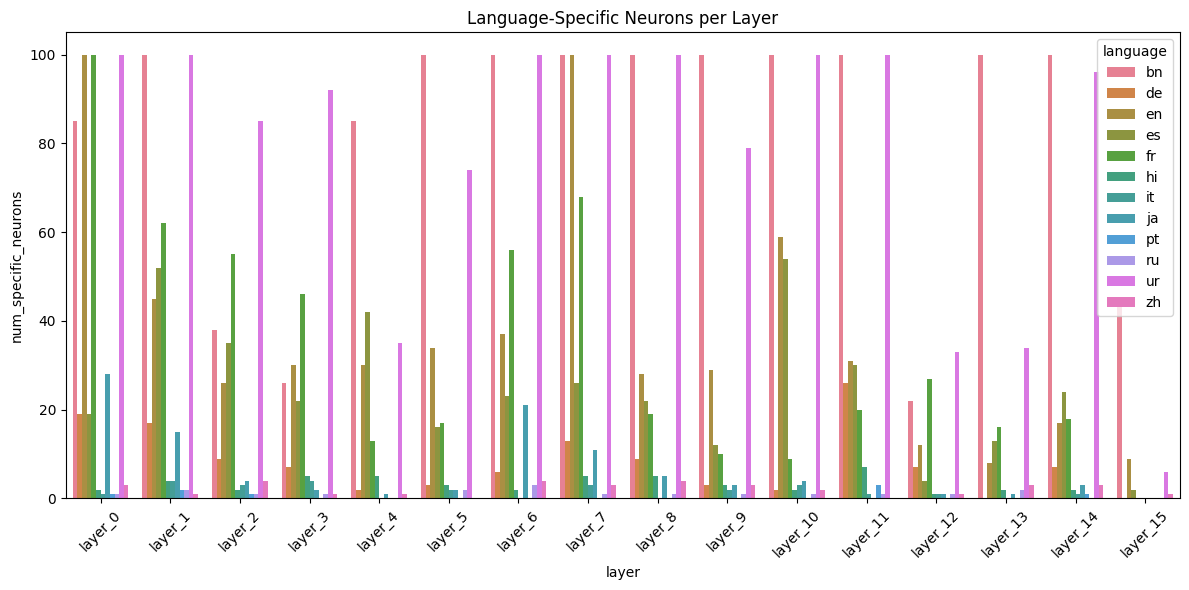

,layer,language,num_specific_neurons
0,layer_0,bn,85
1,layer_0,de,19
2,layer_0,en,100
3,layer_0,es,19
4,layer_0,fr,100


In [4]:
lang_counts = []
for layer, (lang_dfs, _) in layer_data.items():
    for lang, df in lang_dfs.items():
        lang_counts.append({
            "layer": layer,
            "language": lang,
            "num_specific_neurons": len(df)
        })
lang_counts_df = pd.DataFrame(lang_counts)

plt.figure(figsize=(12,6))
sns.barplot(data=lang_counts_df, x="layer", y="num_specific_neurons", hue="language")
plt.title("Language-Specific Neurons per Layer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

lang_counts_df.head()


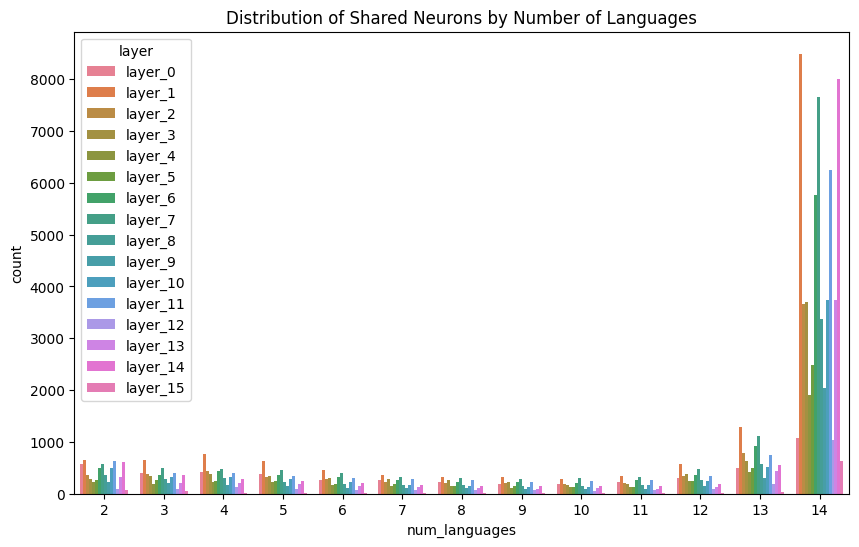

,num_languages,count,layer
0,14,1076,layer_0
1,2,570,layer_0
2,13,496,layer_0
3,4,419,layer_0
4,3,391,layer_0


In [5]:
shared_stats = []
for layer, (_, shared_df) in layer_data.items():
    if shared_df is not None:
        shared_stats.append(shared_df["num_languages"].value_counts().rename_axis("num_languages").reset_index(name="count").assign(layer=layer))

shared_stats_df = pd.concat(shared_stats)

plt.figure(figsize=(10,6))
sns.barplot(data=shared_stats_df, x="num_languages", y="count", hue="layer")
plt.title("Distribution of Shared Neurons by Number of Languages")
plt.show()

shared_stats_df.head()


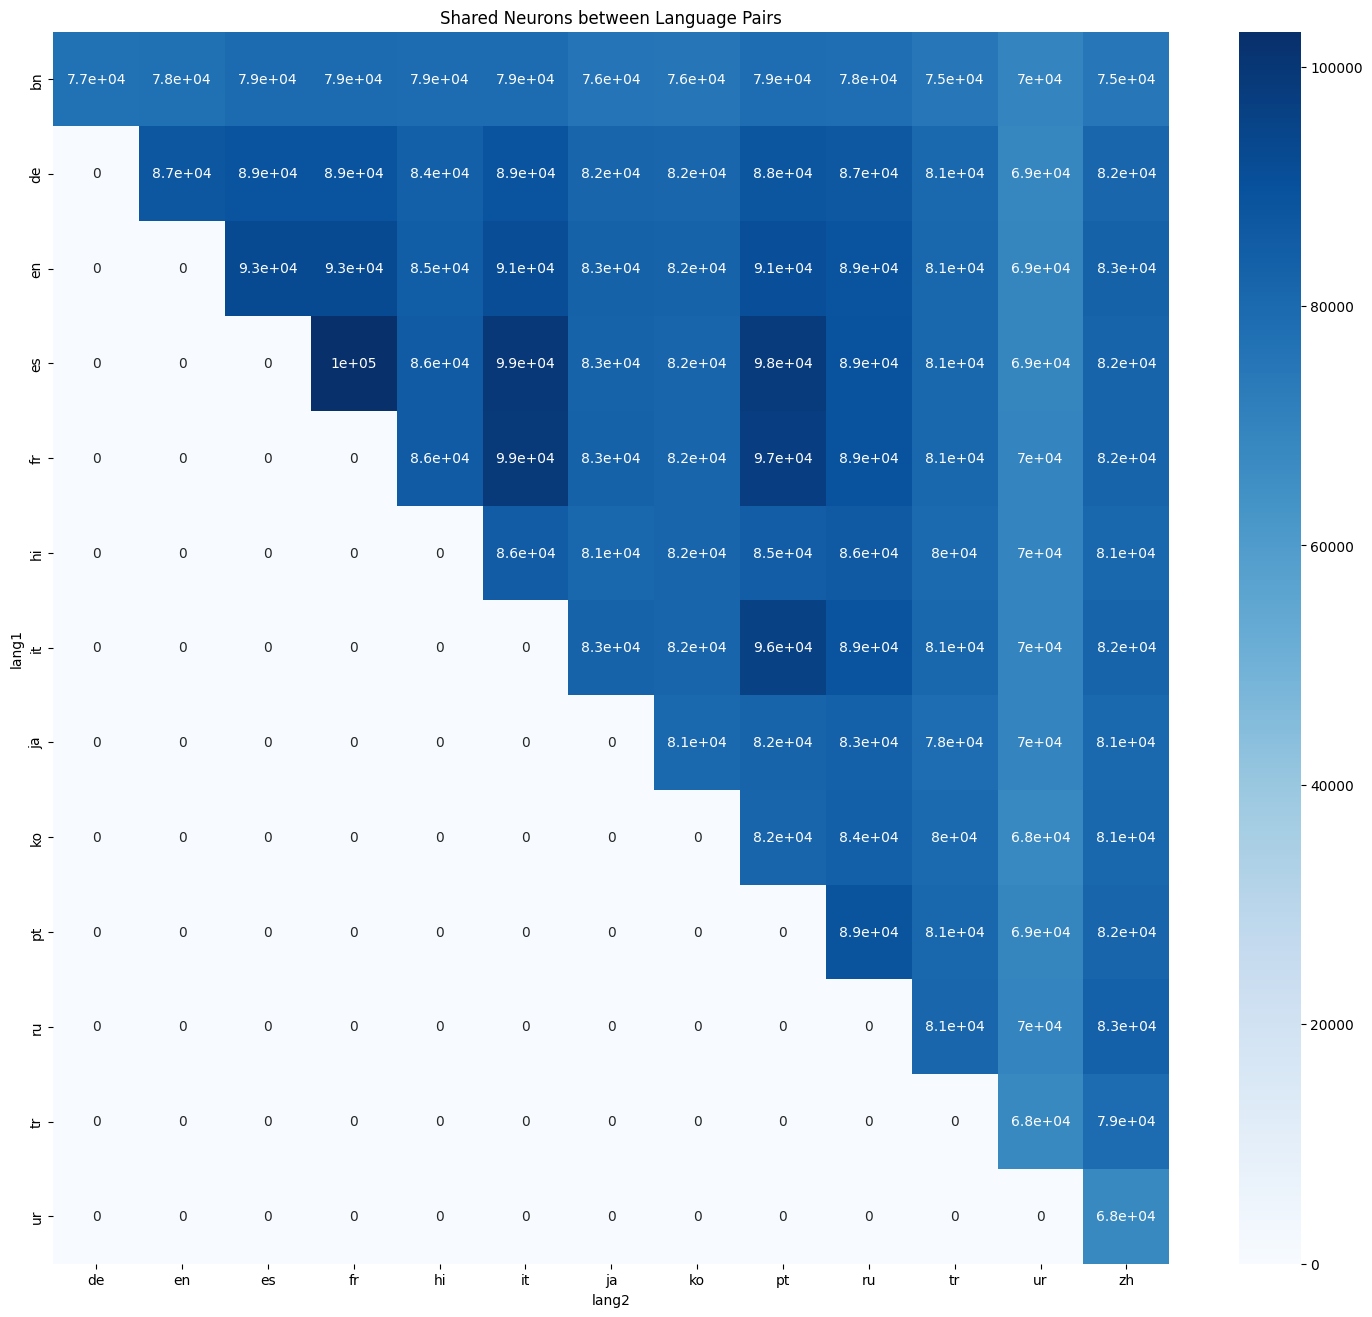

In [8]:
from collections import Counter
import itertools

pair_counts = Counter()
for layer, (_, shared_df) in layer_data.items():
    if shared_df is not None:
        for langs in shared_df["languages"]:
            langs = langs.split(",")
            for pair in itertools.combinations(sorted(langs), 2):
                pair_counts[pair] += 1

pair_df = pd.DataFrame(pair_counts.items(), columns=["pair", "count"])
pair_df["lang1"], pair_df["lang2"] = zip(*pair_df["pair"])
pivot = pair_df.pivot(index="lang1", columns="lang2", values="count").fillna(0)

plt.figure(figsize=(18,16))
sns.heatmap(pivot, cmap="Blues", annot=True, annot_kws={"size": 10})
plt.title("Shared Neurons between Language Pairs")
plt.show()


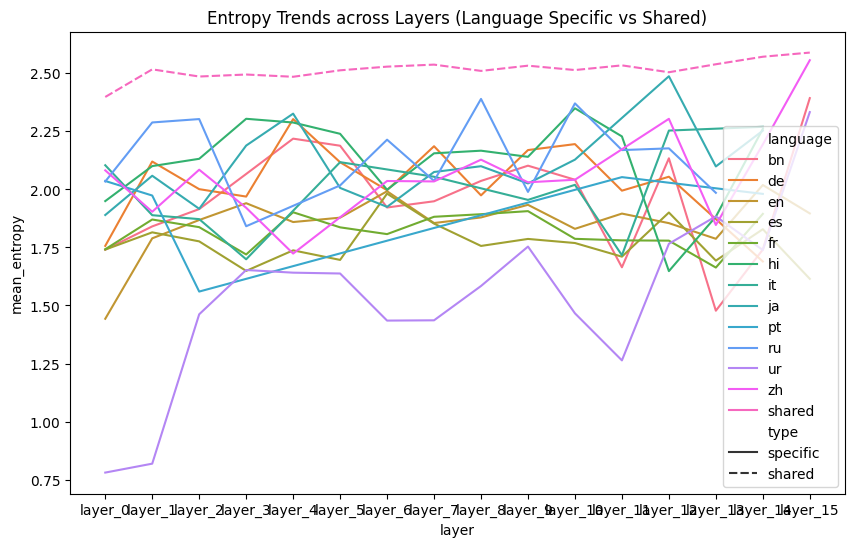

In [9]:
import numpy as np

entropy_summary = []
for layer, (lang_dfs, shared_df) in layer_data.items():
    for lang, df in lang_dfs.items():
        entropy_summary.append({
            "layer": layer,
            "language": lang,
            "type": "specific",
            "mean_entropy": np.mean(df["entropy"])
        })
    if shared_df is not None:
        entropy_summary.append({
            "layer": layer,
            "language": "shared",
            "type": "shared",
            "mean_entropy": np.mean(shared_df["entropy"])
        })

entropy_df = pd.DataFrame(entropy_summary)

plt.figure(figsize=(10,6))
sns.lineplot(data=entropy_df, x="layer", y="mean_entropy", hue="language", style="type")
plt.title("Entropy Trends across Layers (Language Specific vs Shared)")
plt.show()


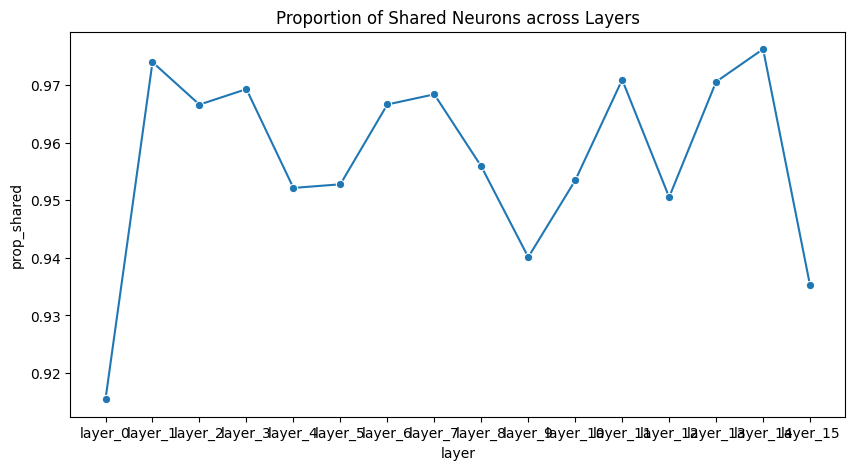

,layer,specific,shared,prop_shared
0,layer_0,459,4969,0.915438
1,layer_1,404,15122,0.973979
2,layer_2,263,7612,0.966603
3,layer_3,236,7449,0.969291
4,layer_4,214,4256,0.952125


In [10]:
proportions = []
for layer, (lang_dfs, shared_df) in layer_data.items():
    total_specific = sum(len(df) for df in lang_dfs.values())
    total_shared = len(shared_df) if shared_df is not None else 0
    proportions.append({
        "layer": layer,
        "specific": total_specific,
        "shared": total_shared,
        "prop_shared": total_shared / (total_specific + total_shared + 1e-9)
    })

proportions_df = pd.DataFrame(proportions)

plt.figure(figsize=(10,5))
sns.lineplot(data=proportions_df, x="layer", y="prop_shared", marker="o")
plt.title("Proportion of Shared Neurons across Layers")
plt.show()

proportions_df.head()


In [35]:
# cell 1 (modified)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set(style="whitegrid")

def safe_read_csv(path):
    """Return DataFrame or None if file is empty or unreadable."""
    try:
        if path.stat().st_size == 0:
            return None
        df = pd.read_csv(path)
        if df.shape[0] == 0:
            return None
        return df
    except Exception:
        return None

# master collection across all layers
all_layers_data = []
layer_summaries = []

for layer_num in range(16):
    base_dir = Path(f"lang2vec_probing/results/{layer_num}/flores_plus-shared-flores_plus")
    if not base_dir.exists():
        print(f"[Layer {layer_num}] ⚠️ Base dir not found: {base_dir}")
        continue

    all_files = sorted([p for p in base_dir.iterdir() if p.suffix == ".csv"])
    print(f"[Layer {layer_num}] Found {len(all_files)} CSVs")

    loaded = {}
    empty_files = []
    for p in all_files:
        df = safe_read_csv(p)
        if df is None:
            empty_files.append(p.name)
            continue

        # normalize columns
        df.columns = [c.strip() for c in df.columns]
        if "r2_score" not in df.columns and "r2" in df.columns:
            df = df.rename(columns={"r2": "r2_score"})

        # --- robust data_type classification ---
        fname = p.name.lower()
        if fname.endswith("with_sources.csv"):
            df["data_type"] = "with_sources"
        elif fname.endswith("shared.csv"):
            df["data_type"] = "shared"
        else:
            df["data_type"] = "unknown"

        # add metadata
        df["file_name"] = p.name
        df["probe_type"] = p.name.split("_probes_")[0]
        df["layer"] = layer_num

        loaded[p.name] = df

    if len(loaded) == 0:
        print(f"[Layer {layer_num}] No valid CSVs loaded.")
        continue

    layer_df = pd.concat(loaded.values(), ignore_index=True)
    all_layers_data.append(layer_df)

    counts = layer_df["data_type"].value_counts().to_dict()
    num_shared = counts.get("shared", 0)
    num_sources = counts.get("with_sources", 0)
    total = num_shared + num_sources
    layer_summaries.append({
        "layer": layer_num,
        "shared": num_shared,
        "with_sources": num_sources,
        "total": total,
        "empty_files": len(empty_files)
    })

    print(f"[Layer {layer_num}] ✅ Shared: {num_shared:,} | With sources: {num_sources:,} | Total: {total:,} | Empty: {len(empty_files)}")

# ---- combine all layers into one master DataFrame ----
if all_layers_data:
    all_probe_data = pd.concat(all_layers_data, ignore_index=True)
    print(f"\n✅ Combined data shape: {all_probe_data.shape}")
else:
    all_probe_data = pd.DataFrame()
    print("⚠️ No valid data loaded from any layer!")

# summary table
layer_counts_df = pd.DataFrame(layer_summaries)
display(layer_counts_df)


[Layer 0] Found 44 CSVs
[Layer 0] ✅ Shared: 5,480,807 | With sources: 508,483 | Total: 5,989,290 | Empty: 8
[Layer 1] Found 22 CSVs
[Layer 1] ✅ Shared: 16,679,566 | With sources: 0 | Total: 16,679,566 | Empty: 4
[Layer 2] Found 44 CSVs
[Layer 2] ✅ Shared: 8,396,036 | With sources: 290,089 | Total: 8,686,125 | Empty: 8
[Layer 3] Found 44 CSVs
[Layer 3] ✅ Shared: 8,216,247 | With sources: 261,411 | Total: 8,477,658 | Empty: 8
[Layer 4] Found 44 CSVs
[Layer 4] ✅ Shared: 4,694,368 | With sources: 237,145 | Total: 4,931,513 | Empty: 8
[Layer 5] Found 44 CSVs
[Layer 5] ✅ Shared: 5,627,506 | With sources: 280,162 | Total: 5,907,668 | Empty: 8
[Layer 6] Found 44 CSVs
[Layer 6] ✅ Shared: 11,243,982 | With sources: 388,256 | Total: 11,632,238 | Empty: 8
[Layer 7] Found 44 CSVs
[Layer 7] ✅ Shared: 14,528,716 | With sources: 476,496 | Total: 15,005,212 | Empty: 8
[Layer 8] Found 22 CSVs
[Layer 8] ✅ Shared: 7,106,629 | With sources: 0 | Total: 7,106,629 | Empty: 4
[Layer 9] Found 44 CSVs
[Layer 9] 

,layer,shared,with_sources,total,empty_files
0,0,5480807,508483,5989290,8
1,1,16679566,0,16679566,4
2,2,8396036,290089,8686125,8
3,3,8216247,261411,8477658,8
4,4,4694368,237145,4931513,8
5,5,5627506,280162,5907668,8
6,6,11243982,388256,11632238,8
7,7,14528716,476496,15005212,8
8,8,7106629,0,7106629,4
9,9,4241035,272441,4513476,8


In [42]:
print(len(all_layers_data))

16


In [47]:
# ---- Combine all layers ----
if all_layers_data:
    all_probe_data = pd.concat(all_layers_data, ignore_index=True)
    print(f"\n✅ Combined data shape: {all_probe_data.shape}")
else:
    all_probe_data = pd.DataFrame()
    print("⚠️ No valid data loaded from any layer!")


✅ Combined data shape: (131485321, 11)


In [48]:
print(len(all_probe_data))

131485321


In [49]:
def categorize_probe(p):
    if p.startswith("fam"):
        return "family"
    if p.startswith("geo"):
        return "geography"
    if p.startswith("id"):
        return "identity"
    if p.startswith("inventory"):
        return "phoneme_inventory"
    if p.startswith("phonology"):
        return "phonology"
    if p.startswith("syntax"):
        return "syntax"
    return "other"

if all_probe_data.empty:
    raise RuntimeError("No probe data found! Check directories or CSV contents.")

all_probe_data["category"] = all_probe_data["probe_type"].apply(categorize_probe)

# ensure numeric types
for col in ["layer", "neuron_idx", "r2_score"]:
    if col in all_probe_data.columns:
        all_probe_data[col] = pd.to_numeric(all_probe_data[col], errors="coerce")

# Drop NaN R²
all_probe_data = all_probe_data.dropna(subset=["r2_score"])

print("Data type counts:")
print(all_probe_data["data_type"].value_counts())
print("\nCategory counts:")
print(all_probe_data["category"].value_counts())


Data type counts:
data_type
shared          127727400
with_sources      3757921
Name: count, dtype: int64

Category counts:
category
phoneme_inventory    51616631
geography            35642893
syntax               29920957
phonology             6556385
family                6079557
identity              1668898
Name: count, dtype: int64


In [50]:
print(len(all_probe_data))

131485321


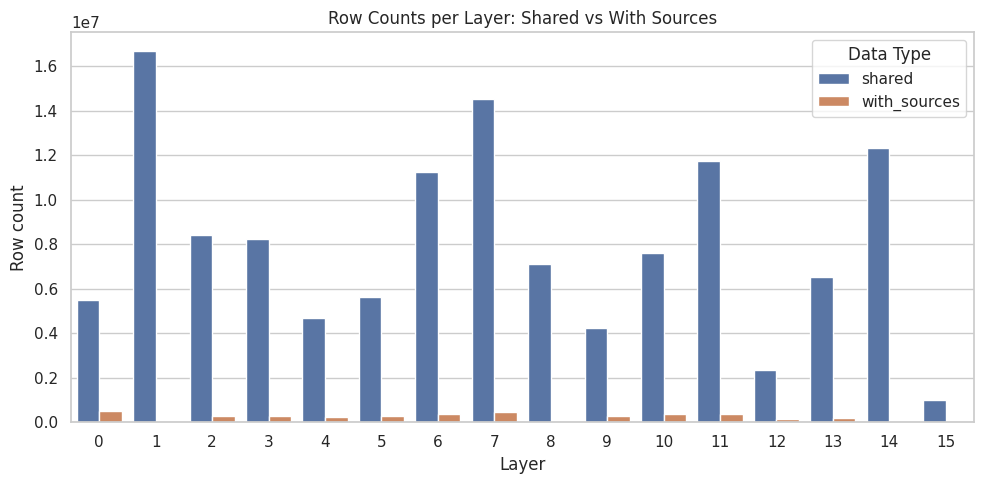

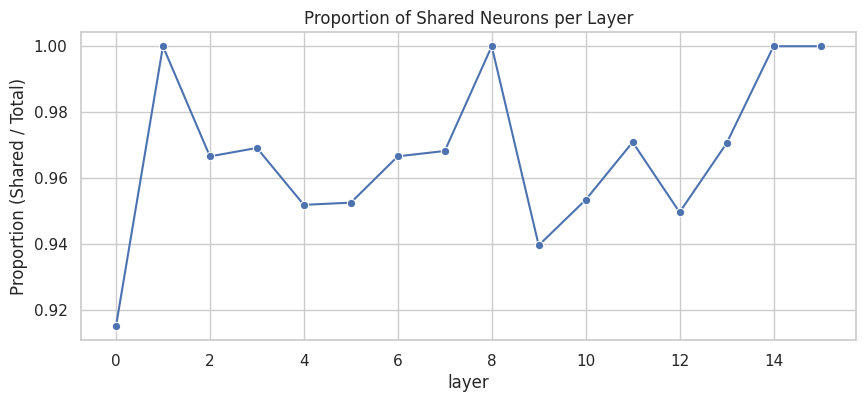

In [52]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=layer_counts_df.melt(id_vars="layer", value_vars=["shared", "with_sources"]),
    x="layer", y="value", hue="variable"
)
plt.title("Row Counts per Layer: Shared vs With Sources")
plt.ylabel("Row count")
plt.xlabel("Layer")
plt.legend(title="Data Type")
plt.tight_layout()
plt.show()

# Optional: proportion shared
layer_counts_df["prop_shared"] = layer_counts_df["shared"] / (layer_counts_df["total"] + 1e-9)
plt.figure(figsize=(10,4))
sns.lineplot(data=layer_counts_df, x="layer", y="prop_shared", marker="o")
plt.title("Proportion of Shared Neurons per Layer")
plt.ylabel("Proportion (Shared / Total)")
plt.show()


In [ ]:
plt.figure(figsize=(12,6))
plot_df = all_probe_data.copy()
plot_df["r2_score_clipped"] = plot_df["r2_score"].clip(lower=-0.05, upper=1.0)

sns.boxplot(
    data=plot_df,
    x="category",
    y="r2_score_clipped",
    hue="data_type"
)
plt.title("Distribution of R² Scores by Linguistic Category (All Layers)")
plt.ylabel("R² (clipped)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


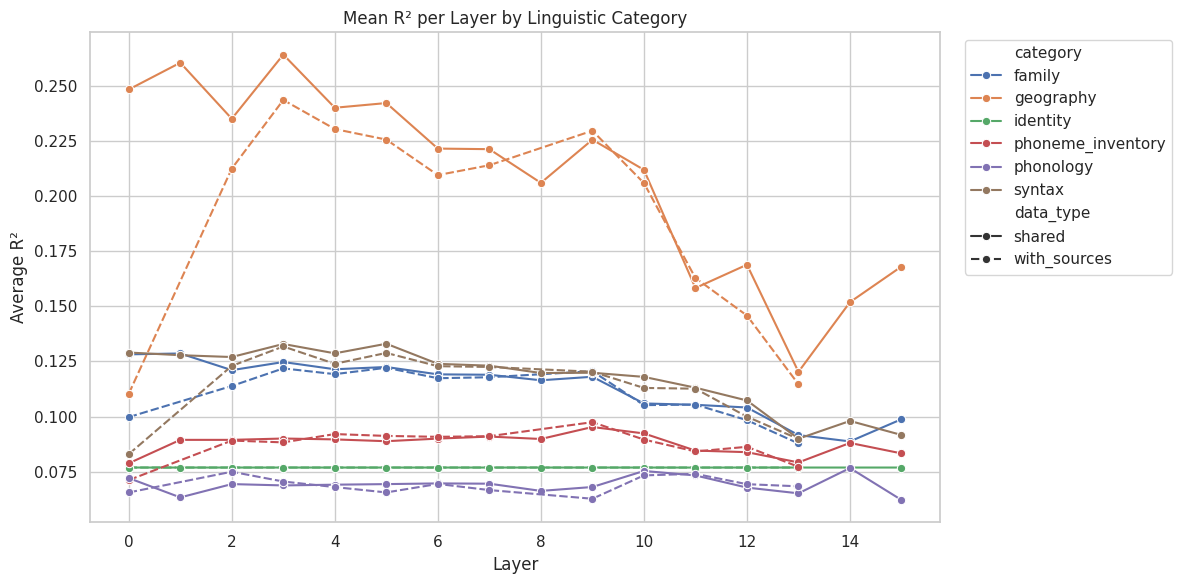

In [53]:
layer_summary = (
    all_probe_data.groupby(["layer", "category", "data_type"])["r2_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=layer_summary,
    x="layer",
    y="r2_score",
    hue="category",
    style="data_type",
    marker="o"
)
plt.title("Mean R² per Layer by Linguistic Category")
plt.ylabel("Average R²")
plt.xlabel("Layer")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


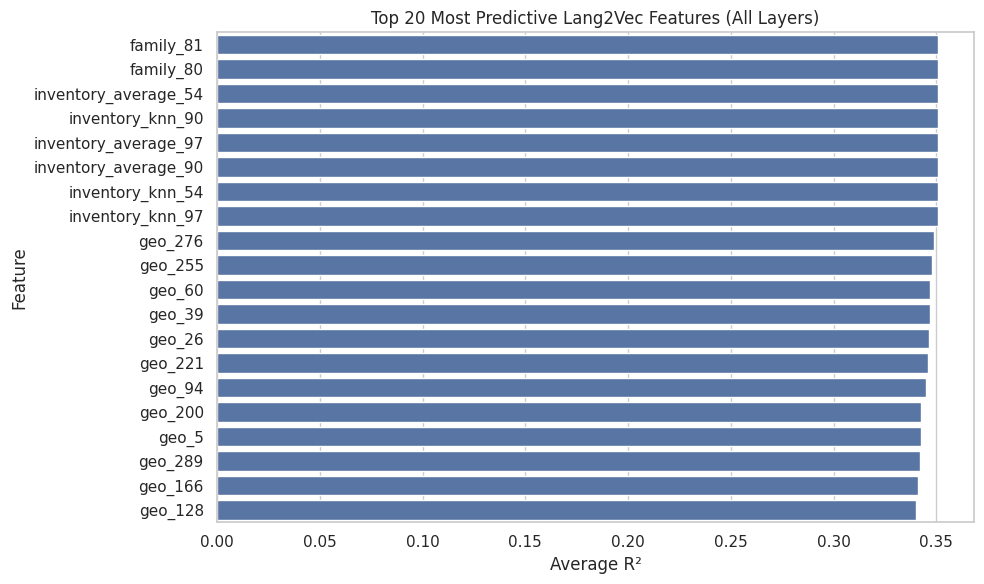

In [54]:
top_feats = (
    all_probe_data.groupby("feature_name")["r2_score"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=top_feats, x="r2_score", y="feature_name")
plt.title("Top 20 Most Predictive Lang2Vec Features (All Layers)")
plt.xlabel("Average R²")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


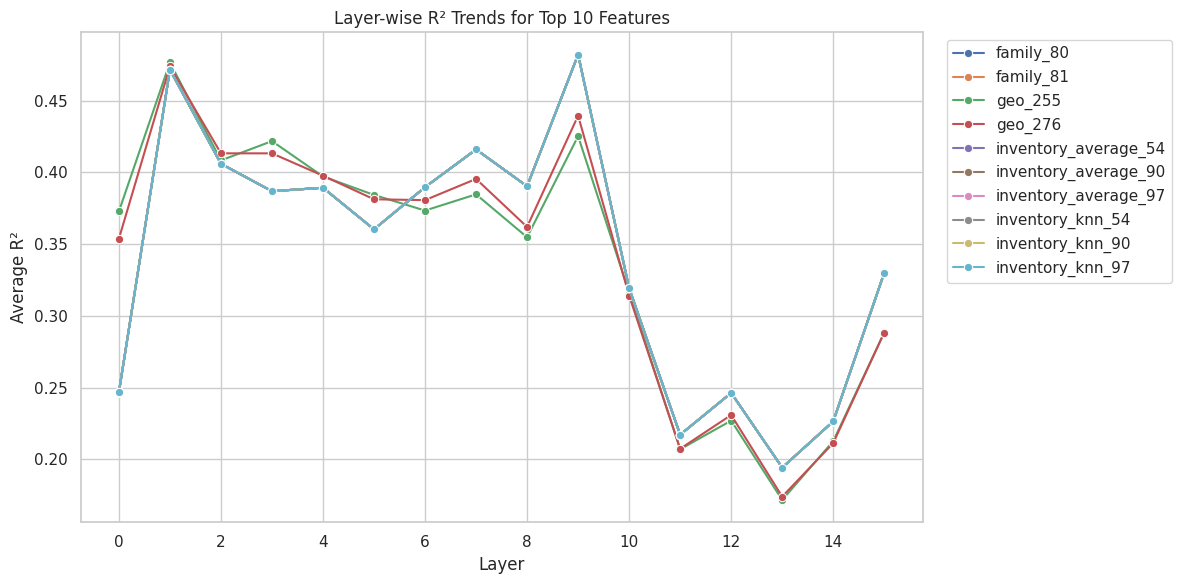

In [55]:
top_feature_names = top_feats["feature_name"].dropna().tolist()[:10]
traj_df = (
    all_probe_data[all_probe_data["feature_name"].isin(top_feature_names)]
    .groupby(["layer", "feature_name"])["r2_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(data=traj_df, x="layer", y="r2_score", hue="feature_name", marker="o")
plt.title("Layer-wise R² Trends for Top 10 Features")
plt.ylabel("Average R²")
plt.xlabel("Layer")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


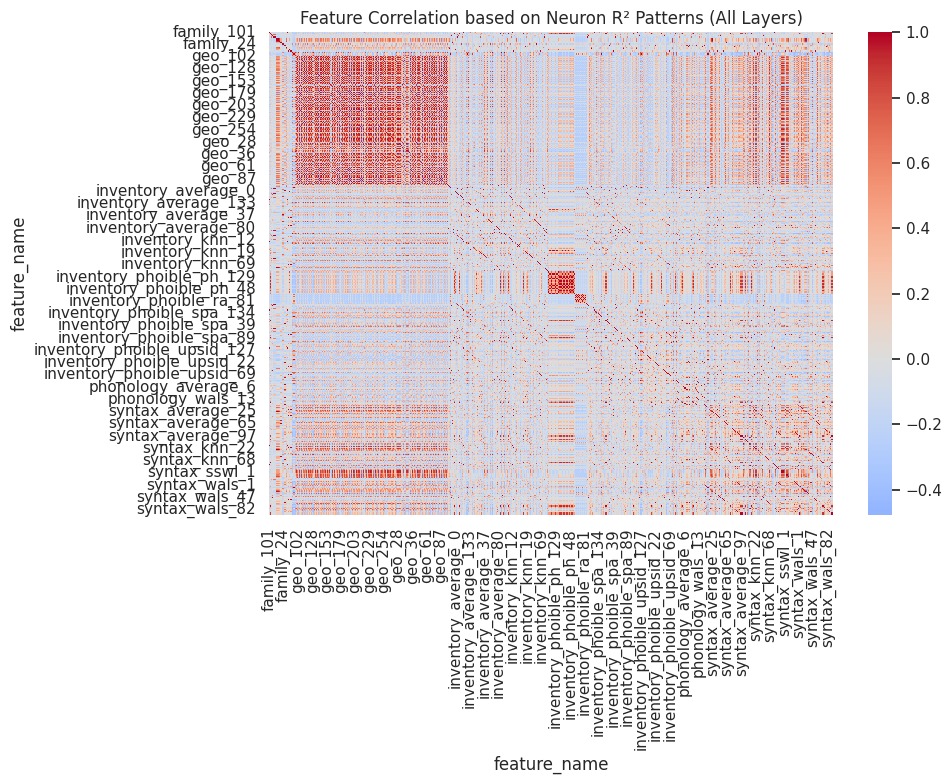

In [56]:
pivot = all_probe_data.pivot_table(
    index=["layer", "neuron_idx", "data_type"],
    columns="feature_name",
    values="r2_score",
    aggfunc="mean",
    fill_value=0
)
if pivot.shape[1] > 1 and pivot.shape[0] > 5:
    corr = pivot.corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Feature Correlation based on Neuron R² Patterns (All Layers)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to compute feature correlations.")


In [57]:
# Cell: Proportion and number of high-R² (> 0.5) neurons per category and layer
# -------------------------------------------------------------------------
THRESHOLD = 0.5

# Filter high-R² entries
high_r2_df = all_probe_data[all_probe_data["r2_score"] > THRESHOLD].copy()
print(f"Found {len(high_r2_df):,} high-R² (> {THRESHOLD}) rows out of {len(all_probe_data):,} total.")

# Count per layer and category
high_r2_summary = (
    high_r2_df.groupby(["layer", "category", "data_type"])
    .size()
    .reset_index(name="high_r2_count")
)

# Total per layer for normalization
total_per_layer = (
    all_probe_data.groupby(["layer", "data_type"])
    .size()
    .reset_index(name="total_count")
)

# Merge to compute proportions
high_r2_summary = high_r2_summary.merge(total_per_layer, on=["layer", "data_type"], how="left")
high_r2_summary["prop_high_r2"] = high_r2_summary["high_r2_count"] / (high_r2_summary["total_count"] + 1e-9)

display(high_r2_summary.head(10))


Found 7,013,465 high-R² (> 0.5) rows out of 131,485,321 total.


,layer,category,data_type,high_r2_count,total_count,prop_high_r2
0,0,family,shared,15658,5480807,0.002857
1,0,family,with_sources,1388,508483,0.002730
2,0,geography,shared,233770,5480807,0.042652
3,0,geography,with_sources,1592,508483,0.003131
4,0,identity,shared,1644,5480807,0.000300
5,0,identity,with_sources,398,508483,0.000783
6,0,phoneme_inventory,shared,30133,5480807,0.005498
7,0,phoneme_inventory,with_sources,4665,508483,0.009174
8,0,phonology,shared,2275,5480807,0.000415
9,0,phonology,with_sources,311,508483,0.000612


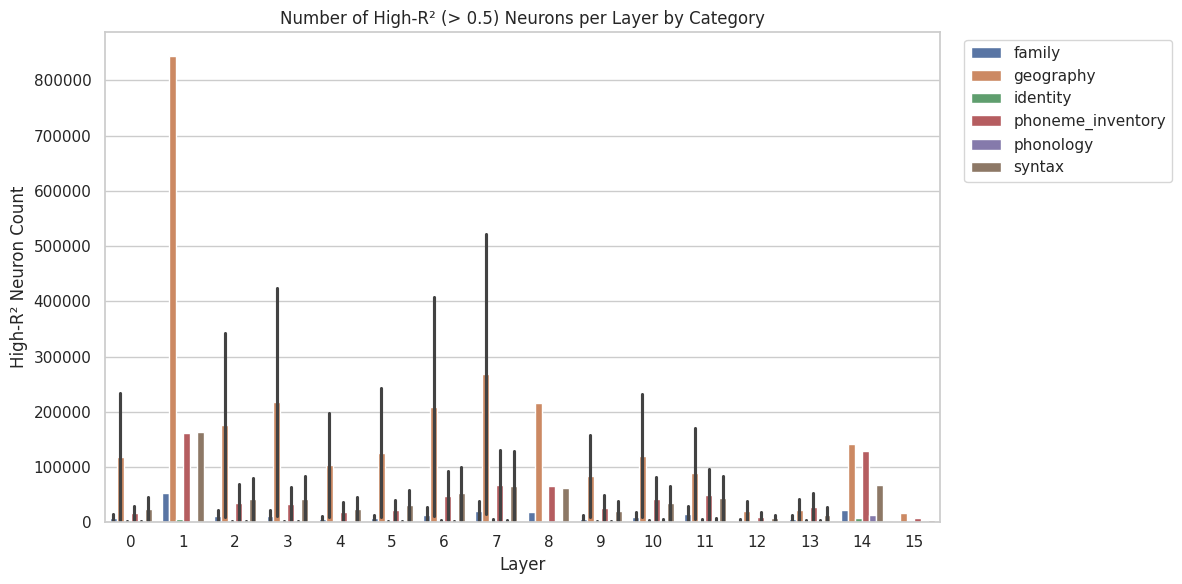

In [58]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=high_r2_summary,
    x="layer",
    y="high_r2_count",
    hue="category"
)
plt.title(f"Number of High-R² (> {THRESHOLD}) Neurons per Layer by Category")
plt.ylabel("High-R² Neuron Count")
plt.xlabel("Layer")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


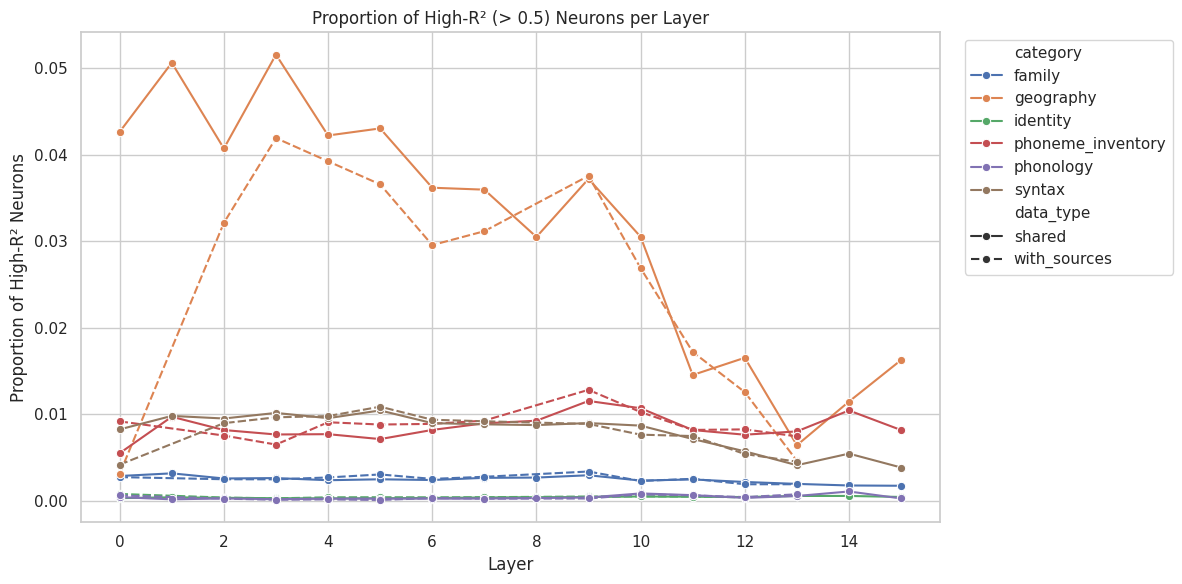

In [59]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=high_r2_summary,
    x="layer",
    y="prop_high_r2",
    hue="category",
    style="data_type",
    marker="o"
)
plt.title(f"Proportion of High-R² (> {THRESHOLD}) Neurons per Layer")
plt.ylabel("Proportion of High-R² Neurons")
plt.xlabel("Layer")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


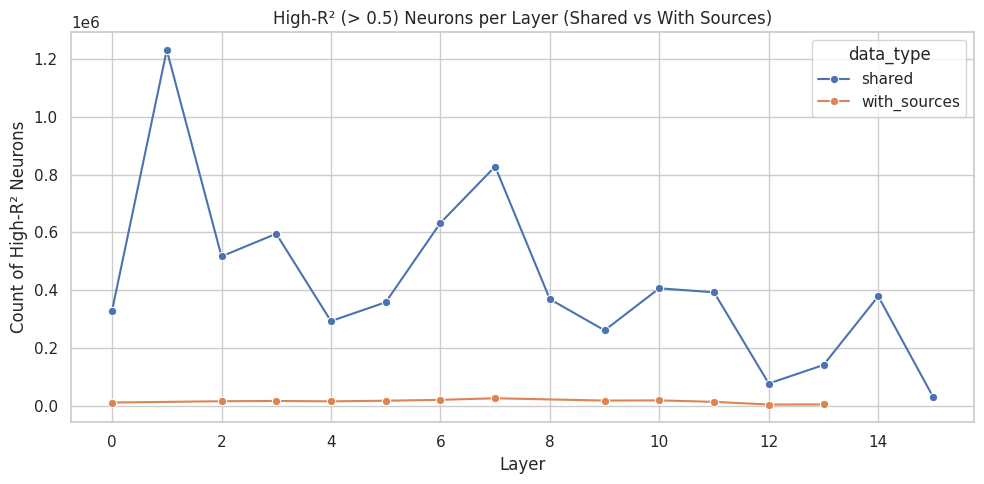

In [60]:
agg_shared = (
    high_r2_summary.groupby(["layer", "data_type"])["high_r2_count"]
    .sum()
    .reset_index()
)
plt.figure(figsize=(10,5))
sns.lineplot(
    data=agg_shared,
    x="layer",
    y="high_r2_count",
    hue="data_type",
    marker="o"
)
plt.title(f"High-R² (> {THRESHOLD}) Neurons per Layer (Shared vs With Sources)")
plt.ylabel("Count of High-R² Neurons")
plt.xlabel("Layer")
plt.tight_layout()
plt.show()


In [61]:
# --------------------------------------------------------------------
# Count high-R² (> 0.5) neurons per layer, split by data_type and category
# --------------------------------------------------------------------
THRESHOLD = 0.5

# Filter high-R² rows
high_r2_df = all_probe_data[all_probe_data["r2_score"] > THRESHOLD].copy()
print(f"Found {len(high_r2_df):,} high-R² (> {THRESHOLD}) rows out of {len(all_probe_data):,} total.")

# Count per layer × data_type × category
high_r2_counts_cat = (
    high_r2_df.groupby(["layer", "data_type", "category"])
    .size()
    .reset_index(name="high_r2_count")
)

# Total per layer × data_type (for normalization)
total_counts_cat = (
    all_probe_data.groupby(["layer", "data_type"])
    .size()
    .reset_index(name="total_count")
)

# Merge totals for proportions
high_r2_counts_cat = high_r2_counts_cat.merge(total_counts_cat, on=["layer", "data_type"], how="left")
high_r2_counts_cat["prop_high_r2"] = high_r2_counts_cat["high_r2_count"] / (high_r2_counts_cat["total_count"] + 1e-9)

display(high_r2_counts_cat.head(10))


Found 7,013,465 high-R² (> 0.5) rows out of 131,485,321 total.


,layer,data_type,category,high_r2_count,total_count,prop_high_r2
0,0,shared,family,15658,5480807,0.002857
1,0,shared,geography,233770,5480807,0.042652
2,0,shared,identity,1644,5480807,0.000300
3,0,shared,phoneme_inventory,30133,5480807,0.005498
4,0,shared,phonology,2275,5480807,0.000415
5,0,shared,syntax,45199,5480807,0.008247
6,0,with_sources,family,1388,508483,0.002730
7,0,with_sources,geography,1592,508483,0.003131
8,0,with_sources,identity,398,508483,0.000783
9,0,with_sources,phoneme_inventory,4665,508483,0.009174


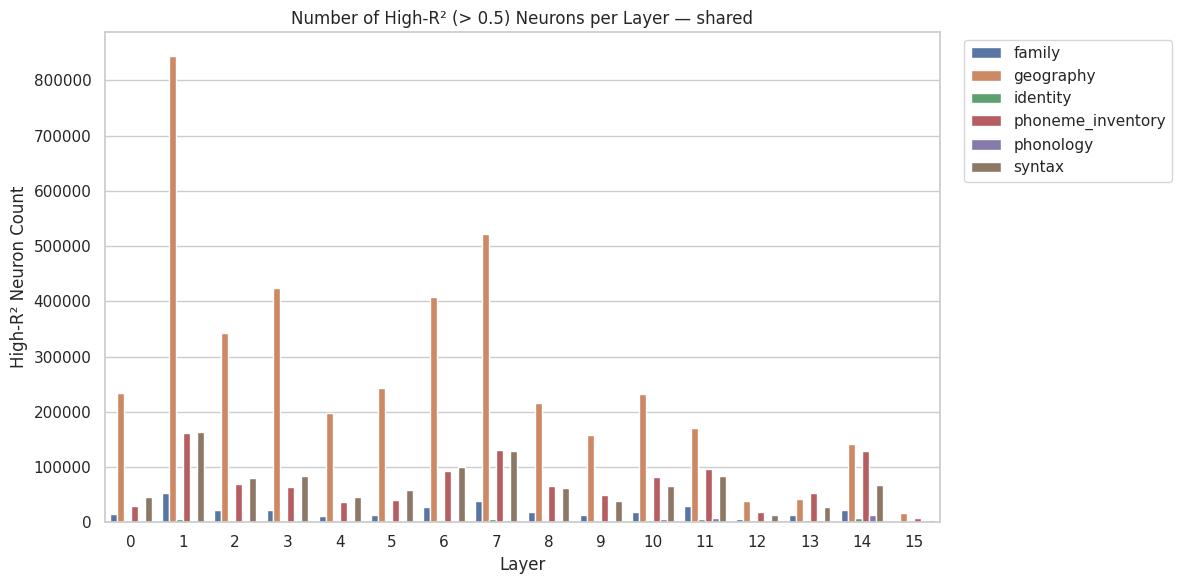

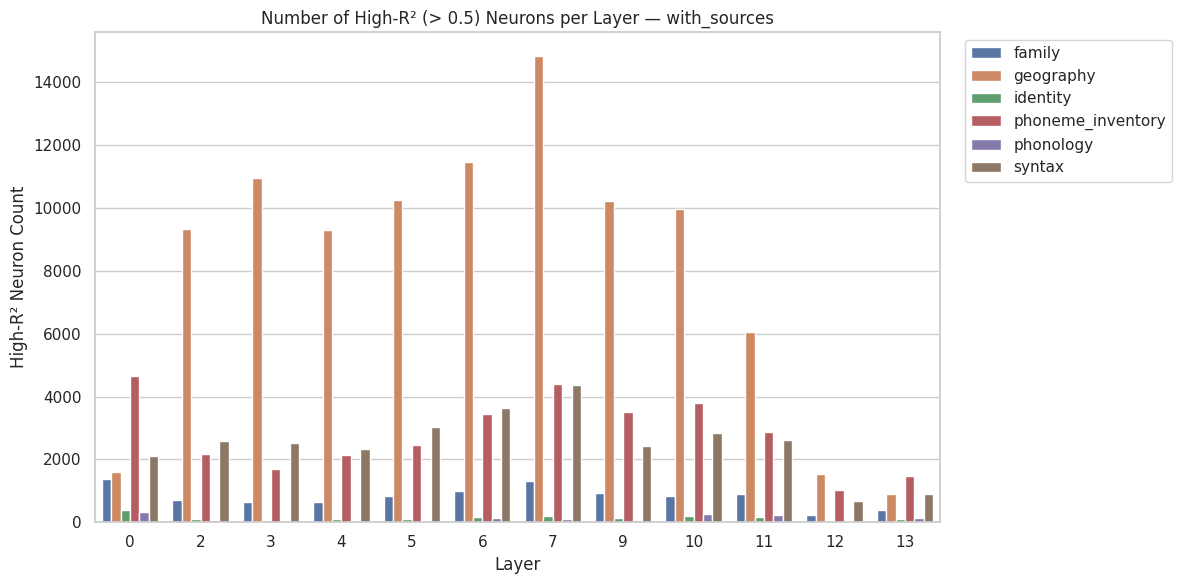

In [62]:
# Separate barplots for shared and with_sources to make comparisons clear
unique_types = high_r2_counts_cat["data_type"].unique()

for dtype in unique_types:
    plt.figure(figsize=(12,6))
    sub = high_r2_counts_cat[high_r2_counts_cat["data_type"] == dtype]
    sns.barplot(data=sub, x="layer", y="high_r2_count", hue="category")
    plt.title(f"Number of High-R² (> {THRESHOLD}) Neurons per Layer — {dtype}")
    plt.ylabel("High-R² Neuron Count")
    plt.xlabel("Layer")
    plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()
